In [157]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import geopandas as gpd

# preamble

# Display more rows and columns
pd.set_option('display.max_rows', 100)  # Default is 60
pd.set_option('display.max_columns', 20)  # Default is 20

# Adjust column width and display width
pd.set_option('display.max_colwidth', None)  # Show full content of each cell
pd.set_option('display.width', 1000)  # Increase the width of the display

## Kaggle Books

In [158]:
# import the dataset
# what does it look like?

books = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Books.csv",",")
ratings = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Ratings.csv",",")
users = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Users.csv",",")

books.head()

<ipython-input-158-857622cb1dac>:4: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only.
  books = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Books.csv",",")
<ipython-input-158-857622cb1dac>:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Books.csv",",")
<ipython-input-158-857622cb1dac>:5: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only.
  ratings = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Ratings.csv",",")
<ipython-input-158-857622cb1dac>:6: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only.
  users = pd.read_csv("/Users/azzambinaamir/book-recommender/data/Users.csv",",")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.LZZZZZZZ.jpg
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.LZZZZZZZ.jpg
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.LZZZZZZZ.jpg
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.LZZZZZZZ.jpg
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.LZZZZZZZ.jpg


In [159]:
#dropping last three columns containing image URLs which will not be required for analysis
books.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'],axis=1,inplace=True)

In [160]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [161]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [162]:
ratings.count()

User-ID        1149780
ISBN           1149780
Book-Rating    1149780
dtype: int64

In [163]:
# Let's see if the ISBN is unique in ratings 

distinct_books_count = books["ISBN"].nunique()

distinct_ratings_count = ratings["ISBN"].nunique() 

print(distinct_books_count,"This is the total number of distinct books in the books dataset")
print(distinct_ratings_count,"This is the total number of distinct books in the ratings dataset")

print()

271360 This is the total number of distinct books in the books dataset
340556 This is the total number of distinct books in the ratings dataset



<AxesSubplot: >

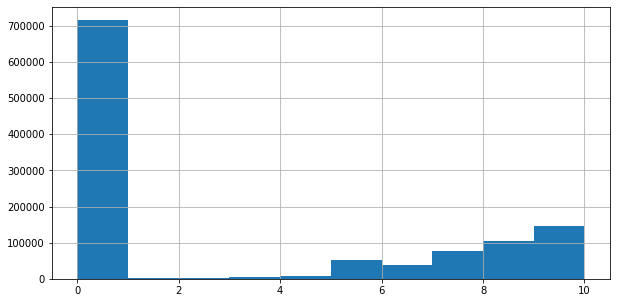

In [164]:
# Let's see the distribution of ratings
ratings["Book-Rating"].hist(bins=10, figsize=(10,5))

In [165]:
ratings["User-ID"].nunique()

105283

In [166]:
by = ["User-ID", "ISBN"]
ratings.groupby(by, axis=0, level=None, as_index=True, sort=True).head()
# this is the unique key 

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


## Consolidate into singular table

In [194]:

ratings_and_books = pd.merge(ratings, books, on="ISBN", how="left")
universal = pd.merge(ratings_and_books, users, on="User-ID", how="left")
universal.sort_values(by=["User-ID", "ISBN"], ascending=True, inplace=True)
universal

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Location,Age
9561,2,0195153448,0,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,"stockton, california, usa",18.0
9562,7,034542252,0,NaN,NaN,NaN,NaN,"washington, dc, usa",NaN
9563,8,0002005018,5,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,"timmins, ontario, canada",NaN
9564,8,0060973129,0,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,"timmins, ontario, canada",NaN
9565,8,0374157065,0,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux,"timmins, ontario, canada",NaN
...,...,...,...,...,...,...,...,...,...
9556,278854,0425163393,7,Kat Scratch Fever (Kat Colorado Mysteries),Karen Kijewski,1998,Berkley Publishing Group,"portland, oregon, usa",NaN
9557,278854,0515087122,0,The Cat Who Ate Danish Modern (Cat Who... (Paperback)),Lilian Jackson Braun,1990,Jove Books,"portland, oregon, usa",NaN
9558,278854,0553275739,6,In Her Day,Rita Mae Brown,1988,Bantam Books,"portland, oregon, usa",NaN
9559,278854,0553578596,0,Wicked Fix : A Home Repair is Homicide Mystery (Home Repair is Homicide Mysteries (Paperback)),SARAH GRAVES,2000,Bantam,"portland, oregon, usa",NaN


In [195]:
universal[universal['Age'].notnull()]

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Location,Age
9561,2,0195153448,0,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,"stockton, california, usa",18.0
9584,10,1841721522,0,New Vegetarian: Bold and Beautiful Recipes for Every Occasion,Celia Brooks Brown,2001,Ryland Peters &amp; Small Ltd,"albacete, wisconsin, spain",26.0
9585,10,8477024456,6,NaN,NaN,NaN,NaN,"albacete, wisconsin, spain",26.0
9600,19,0375759778,7,Prague : A Novel,ARTHUR PHILLIPS,2003,Random House Trade Paperbacks,"weston, ,",14.0
9601,20,0425163091,0,Chocolate Jesus,Stephan Jaramillo,1998,Berkley Publishing Group,"langhorne, pennsylvania, usa",19.0
...,...,...,...,...,...,...,...,...,...
9548,278851,1558531025,8,Life's Little Instruction Book (Life's Little Instruction Books (Paperback)),H. Jackson Brown,1991,Thomas Nelson,"dallas, texas, usa",33.0
9549,278851,1566910102,0,Oregon Handbook (The Americas Series),Stuart Warren,1995,Pub Group West,"dallas, texas, usa",33.0
9550,278851,1569661057,10,"Dallas Street Map Guide and Directory, 2000 Edition",Mapsco,1999,American Map Corporation,"dallas, texas, usa",33.0
9551,278851,1885071213,7,"Highpoint Adventures, A Pocket Guide to the 50 State Highpoints",Charlie Winger,1999,Sequoia Publishing,"dallas, texas, usa",33.0


### Let's get a quick idea of how the data is spread

In [168]:
# what's the most popular book by location?
# where are people reading the most books?
# what age is reading the most books?

In [169]:
# what's the most popular book by age?

# how do we define most popular?
# heighest ratings? most reads?

pop_by_rating = pd.DataFrame(ratings.groupby("ISBN")["Book-Rating"].sum().sort_values(ascending=False))
pop_by_rating.merge(books, on='ISBN', how = "left")

,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0316666343,5787,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
1,0385504209,4108,The Da Vinci Code,Dan Brown,2003,Doubleday
2,0312195516,3134,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA
3,0679781587,2800,NaN,NaN,NaN,NaN
4,059035342X,2798,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,1999,Arthur A. Levine Books
...,...,...,...,...,...,...
340551,082176690,0,NaN,NaN,NaN,NaN
340552,0394724844,0,How to Draw and Paint What You See,Ray Smith,1984,Random House Inc
340553,0821766937,0,After Dark,Beverly Barton,2000,Zebra Books/Kensington Publishing Corp.
340554,0821766945,0,His Scandalous Duchess (Zebra Historical Romance),Sara Blayne,2000,Kensington Publishing Corporation


In [170]:
pop_by_raters = pd.DataFrame(ratings.groupby("ISBN")["User-ID"].nunique().sort_values(ascending=False))

# Rename the column to "count_of_users"
pop_by_raters = pop_by_raters.rename(columns={"User-ID": "count_of_users"})

pop_by_raters.merge(books, on='ISBN', how = "left")

,ISBN,count_of_users,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0971880107,2502,Wild Animus,Rich Shapero,2004,Too Far
1,0316666343,1295,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
2,0385504209,883,The Da Vinci Code,Dan Brown,2003,Doubleday
3,0060928336,732,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,Perennial
4,0312195516,723,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA
...,...,...,...,...,...,...
340551,0801064090,1,A+ Education: Choosing the Best School Option for Your Child,William Eckenwiler,2002,Baker Books
340552,0801064252,1,Face to Face,Linda Dorrell,2002,Baker Books
340553,0801064279,1,"Hoofbeats on the Trail (Ally O'Connor Adventures, 3)",Mark Littleton,2002,Baker Books
340554,0801064333,1,Thank God It's Monday: Celebrating Your Purpose at Work,Kim Hackney,2003,Baker Books


In [171]:
# Now, we can define a metric, rating per reader, to find the most popular books

pop_by_rating_per_reader = pop_by_rating.merge(pop_by_raters, on='ISBN', how = "left")
pop_by_rating_per_reader["rating_per_reader"] = pop_by_rating_per_reader["Book-Rating"] / pop_by_rating_per_reader["count_of_users"]
popularity_ranking = pop_by_rating_per_reader.merge(books, on='ISBN', how = "left")

In [172]:
popularity_ranking

,ISBN,Book-Rating,count_of_users,rating_per_reader,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0316666343,5787,1295,4.468726,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
1,0385504209,4108,883,4.652322,The Da Vinci Code,Dan Brown,2003,Doubleday
2,0312195516,3134,723,4.334716,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA
3,0679781587,2800,639,4.381847,NaN,NaN,NaN,NaN
4,059035342X,2798,571,4.900175,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,1999,Arthur A. Levine Books
...,...,...,...,...,...,...,...,...
340551,082176690,0,1,0.000000,NaN,NaN,NaN,NaN
340552,0394724844,0,1,0.000000,How to Draw and Paint What You See,Ray Smith,1984,Random House Inc
340553,0821766937,0,7,0.000000,After Dark,Beverly Barton,2000,Zebra Books/Kensington Publishing Corp.
340554,0821766945,0,2,0.000000,His Scandalous Duchess (Zebra Historical Romance),Sara Blayne,2000,Kensington Publishing Corporation


### Partitioning the data

Now that we have a basic popularity metric, it'd be interesting to see how these ratings relate to factors like location and age... given that that's all we have hehe

<AxesSubplot: >

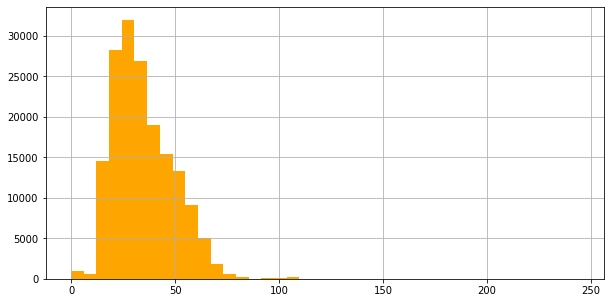

In [173]:
# Let's have some fun visualizing the data

users.Age.hist(bins=40, figsize=(10,5),color='orange')

array([[<AxesSubplot: title={'center': 'Age'}>]], dtype=object)

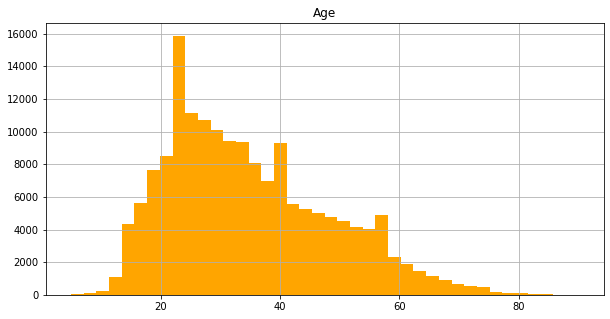

In [184]:
#In my view values below 5 and above 90 do not make much sense for our book rating case...hence replacing these by NaNs
users.loc[(users.Age > 90) | (users.Age < 5), 'Age'] = np.nan

#replacing NaNs with mean - does not work as data is mostly nan values
# users.Age = users.Age.fillna(users.Age.mean())

# let's filter out for now, later can try interpolation

users.filter(["Age"]).dropna().hist(bins=40, figsize=(10,5),color='orange')

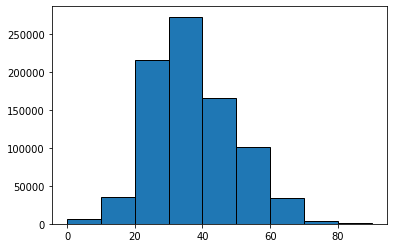

In [180]:
# What age group reads the most?

count, bins = np.histogram(universal.Age.dropna(), bins=range(0, 100, 10))
plt.hist(bins[:-1], bins, weights=count, edgecolor='black')
plt.show()

In [185]:
bins

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [201]:
# What's the most popular book by age?

# First, define the age groups 
age_groups = bins

# Now, have to partition the data into these age groups

labels = [f"{age_group}-{age_group+10}" for age_group in age_groups[:-1]]

# Create a new column in the universal dataframe to store the age group

universal["age_group"] = pd.cut(universal["Age"], bins=age_groups, labels=labels,right=False)
universal

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Location,Age,age_group
9561,2,0195153448,0,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,"stockton, california, usa",18.0,10-20
9562,7,034542252,0,NaN,NaN,NaN,NaN,"washington, dc, usa",NaN,NaN
9563,8,0002005018,5,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,"timmins, ontario, canada",NaN,NaN
9564,8,0060973129,0,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,"timmins, ontario, canada",NaN,NaN
9565,8,0374157065,0,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux,"timmins, ontario, canada",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9556,278854,0425163393,7,Kat Scratch Fever (Kat Colorado Mysteries),Karen Kijewski,1998,Berkley Publishing Group,"portland, oregon, usa",NaN,NaN
9557,278854,0515087122,0,The Cat Who Ate Danish Modern (Cat Who... (Paperback)),Lilian Jackson Braun,1990,Jove Books,"portland, oregon, usa",NaN,NaN
9558,278854,0553275739,6,In Her Day,Rita Mae Brown,1988,Bantam Books,"portland, oregon, usa",NaN,NaN
9559,278854,0553578596,0,Wicked Fix : A Home Repair is Homicide Mystery (Home Repair is Homicide Mysteries (Paperback)),SARAH GRAVES,2000,Bantam,"portland, oregon, usa",NaN,NaN


In [203]:
universal[universal['Age'].notnull()]

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Location,Age,age_group
9561,2,0195153448,0,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,"stockton, california, usa",18.0,10-20
9584,10,1841721522,0,New Vegetarian: Bold and Beautiful Recipes for Every Occasion,Celia Brooks Brown,2001,Ryland Peters &amp; Small Ltd,"albacete, wisconsin, spain",26.0,20-30
9585,10,8477024456,6,NaN,NaN,NaN,NaN,"albacete, wisconsin, spain",26.0,20-30
9600,19,0375759778,7,Prague : A Novel,ARTHUR PHILLIPS,2003,Random House Trade Paperbacks,"weston, ,",14.0,10-20
9601,20,0425163091,0,Chocolate Jesus,Stephan Jaramillo,1998,Berkley Publishing Group,"langhorne, pennsylvania, usa",19.0,10-20
...,...,...,...,...,...,...,...,...,...,...
9548,278851,1558531025,8,Life's Little Instruction Book (Life's Little Instruction Books (Paperback)),H. Jackson Brown,1991,Thomas Nelson,"dallas, texas, usa",33.0,30-40
9549,278851,1566910102,0,Oregon Handbook (The Americas Series),Stuart Warren,1995,Pub Group West,"dallas, texas, usa",33.0,30-40
9550,278851,1569661057,10,"Dallas Street Map Guide and Directory, 2000 Edition",Mapsco,1999,American Map Corporation,"dallas, texas, usa",33.0,30-40
9551,278851,1885071213,7,"Highpoint Adventures, A Pocket Guide to the 50 State Highpoints",Charlie Winger,1999,Sequoia Publishing,"dallas, texas, usa",33.0,30-40


In [202]:
pop_by_age_group = pd.DataFrame(universal.groupby("ISBN","age_group")["Book-Rating"].sum().sort_values(ascending=False))
pop_by_age_group

ValueError: No axis named age_group for object type DataFrame

In [ ]:
# Where are people reading the most books?